In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../code/')
import helper

### Loading in Files

In [2]:
directory = '../data/mssa_channels_kiyan_fast/'

fname_m0_amp = directory+'m0_amp_bins_j20_t16.dat'

fname_m1_amp = directory+'m1_amp_bins_j20_t16.dat'
fname_m1_pitch = directory+'m1_pitch_bins_j20_t16.dat'
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j20_t16.dat'

fname_m2_amp = directory+'m2_amp_bins_j20_t16.dat'
fname_m2_pitch = directory+'m2_pitch_bins_j20_t16.dat'
fname_m2_rel_amp = directory+'m2_amp_rel_bins_j20_t16.dat'


coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m1_pitch0 = pyEXP.coefs.Coefs.factory(fname_m1_pitch)
coefs_m2_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m2_rel_amp)
coefs_m2_pitch0 = pyEXP.coefs.Coefs.factory(fname_m2_pitch)

coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()
coefs_m1_pitch = coefs_m1_pitch0.deepcopy()
coefs_m2_rel_amp = coefs_m2_rel_amp0.deepcopy()
coefs_m2_pitch = coefs_m2_pitch0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [3]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_pitch.getAllCoefs()))
times = coefs_m1_pitch.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]
keylst_m1_pitch = [[i] for i in range(n_channels)]
keylst_m2_amp = [[i] for i in range(n_channels)]
keylst_m2_pitch = [[i] for i in range(n_channels)]

config = {"snails_m1_pitch": (coefs_m1_pitch, keylst_m1_pitch, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [4]:
fig_dir = '../figures/kiyan_fast_figures/'

In [5]:
ev = mssa.eigenvalues()

shape U = 50400 x 151
shape Y = 151 x 50400


In [6]:
coefs_m1_pitch.zerodata()
mssa.reconstruct([*range(30)])

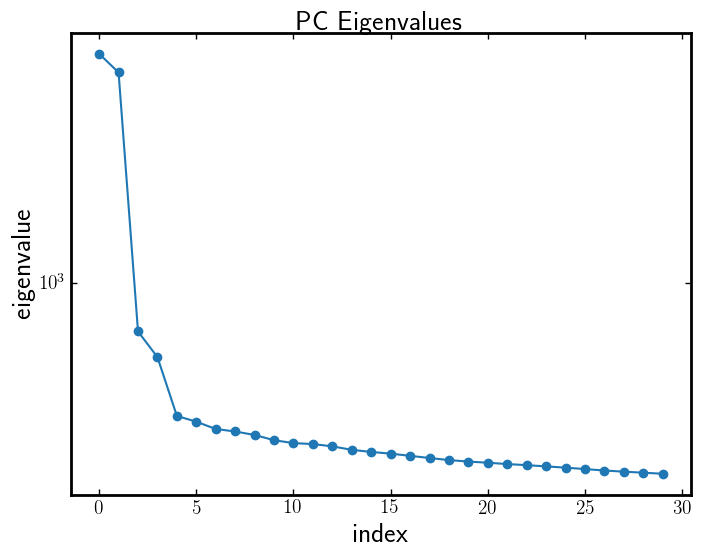

In [7]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

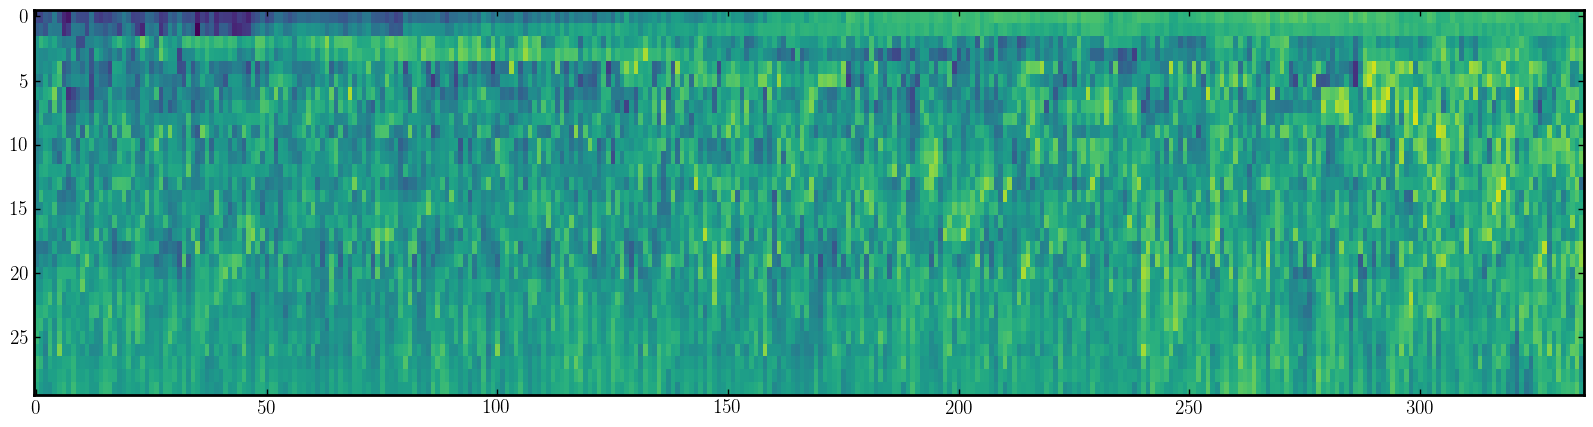

In [8]:
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())

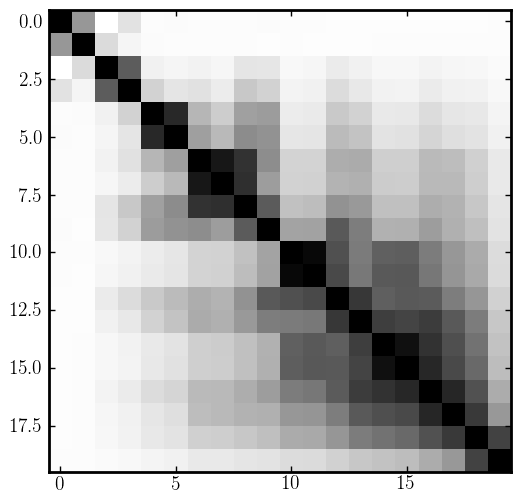

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll()[:20, :20], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

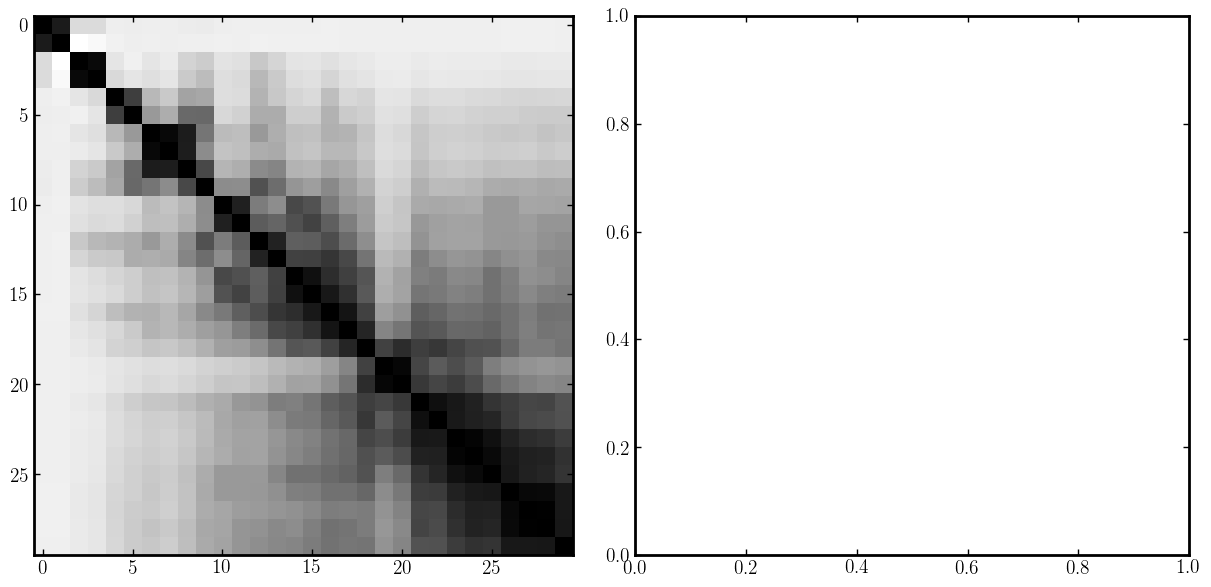

In [10]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
#ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

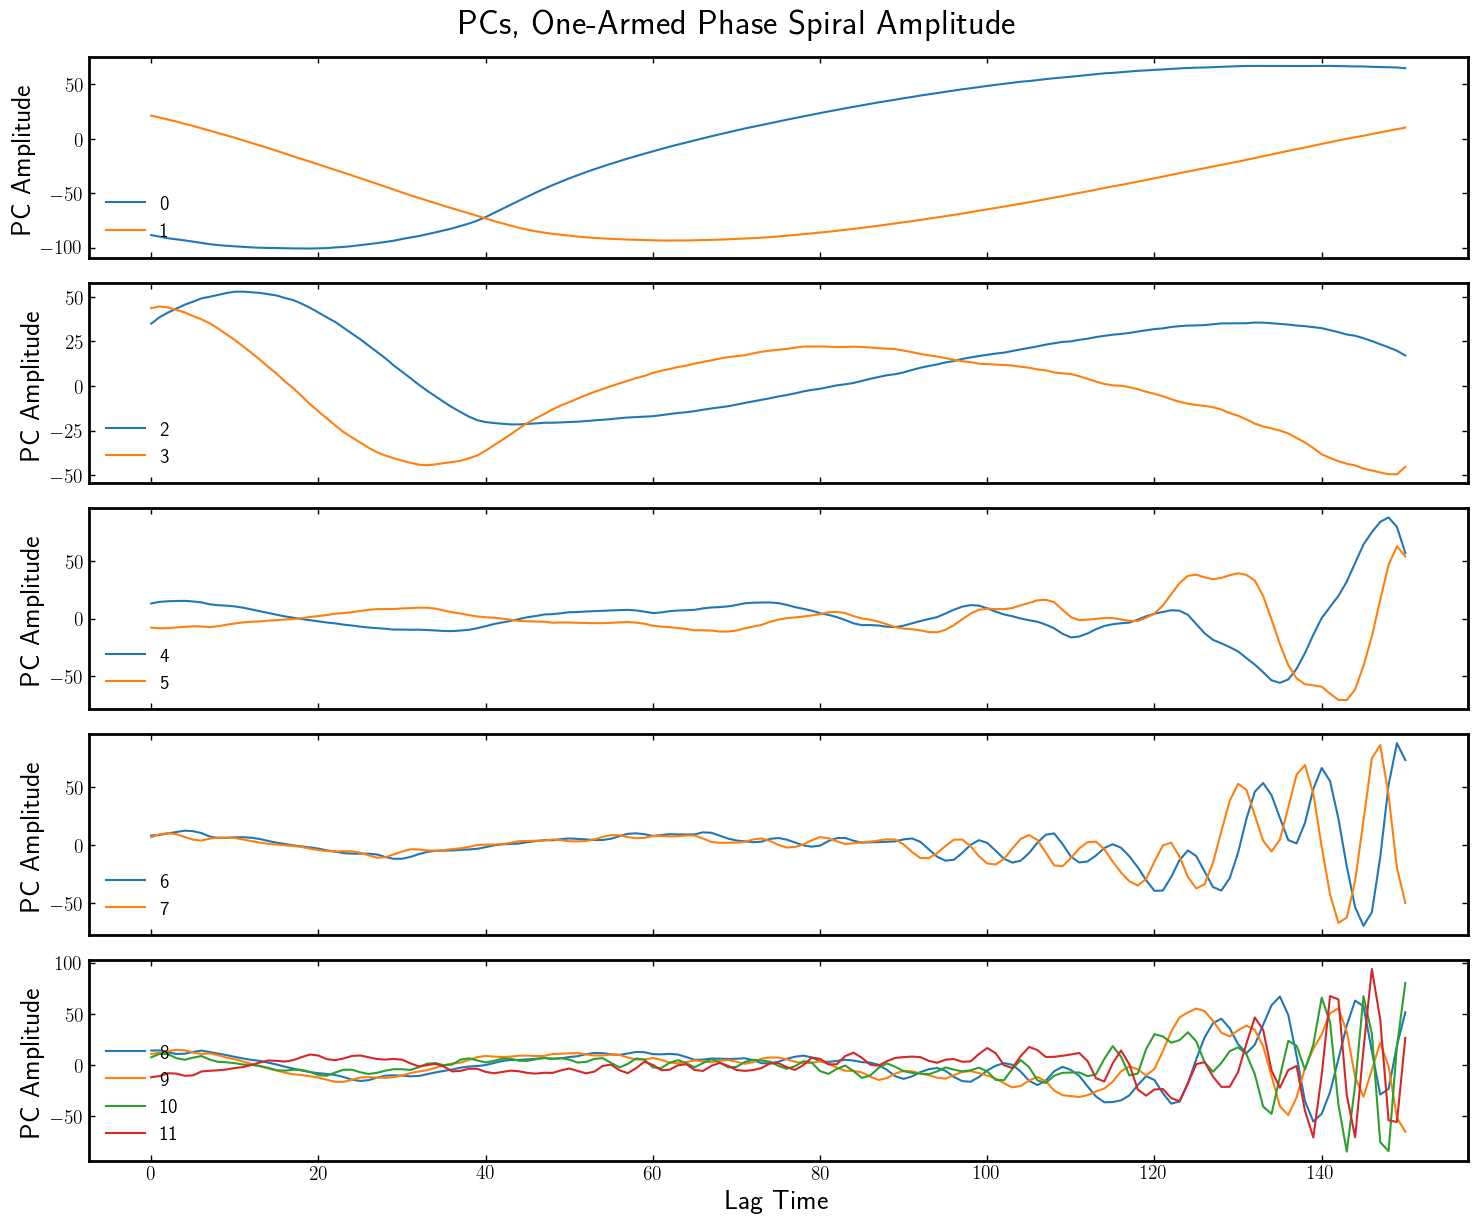

In [11]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral Amplitude', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Amplitude', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

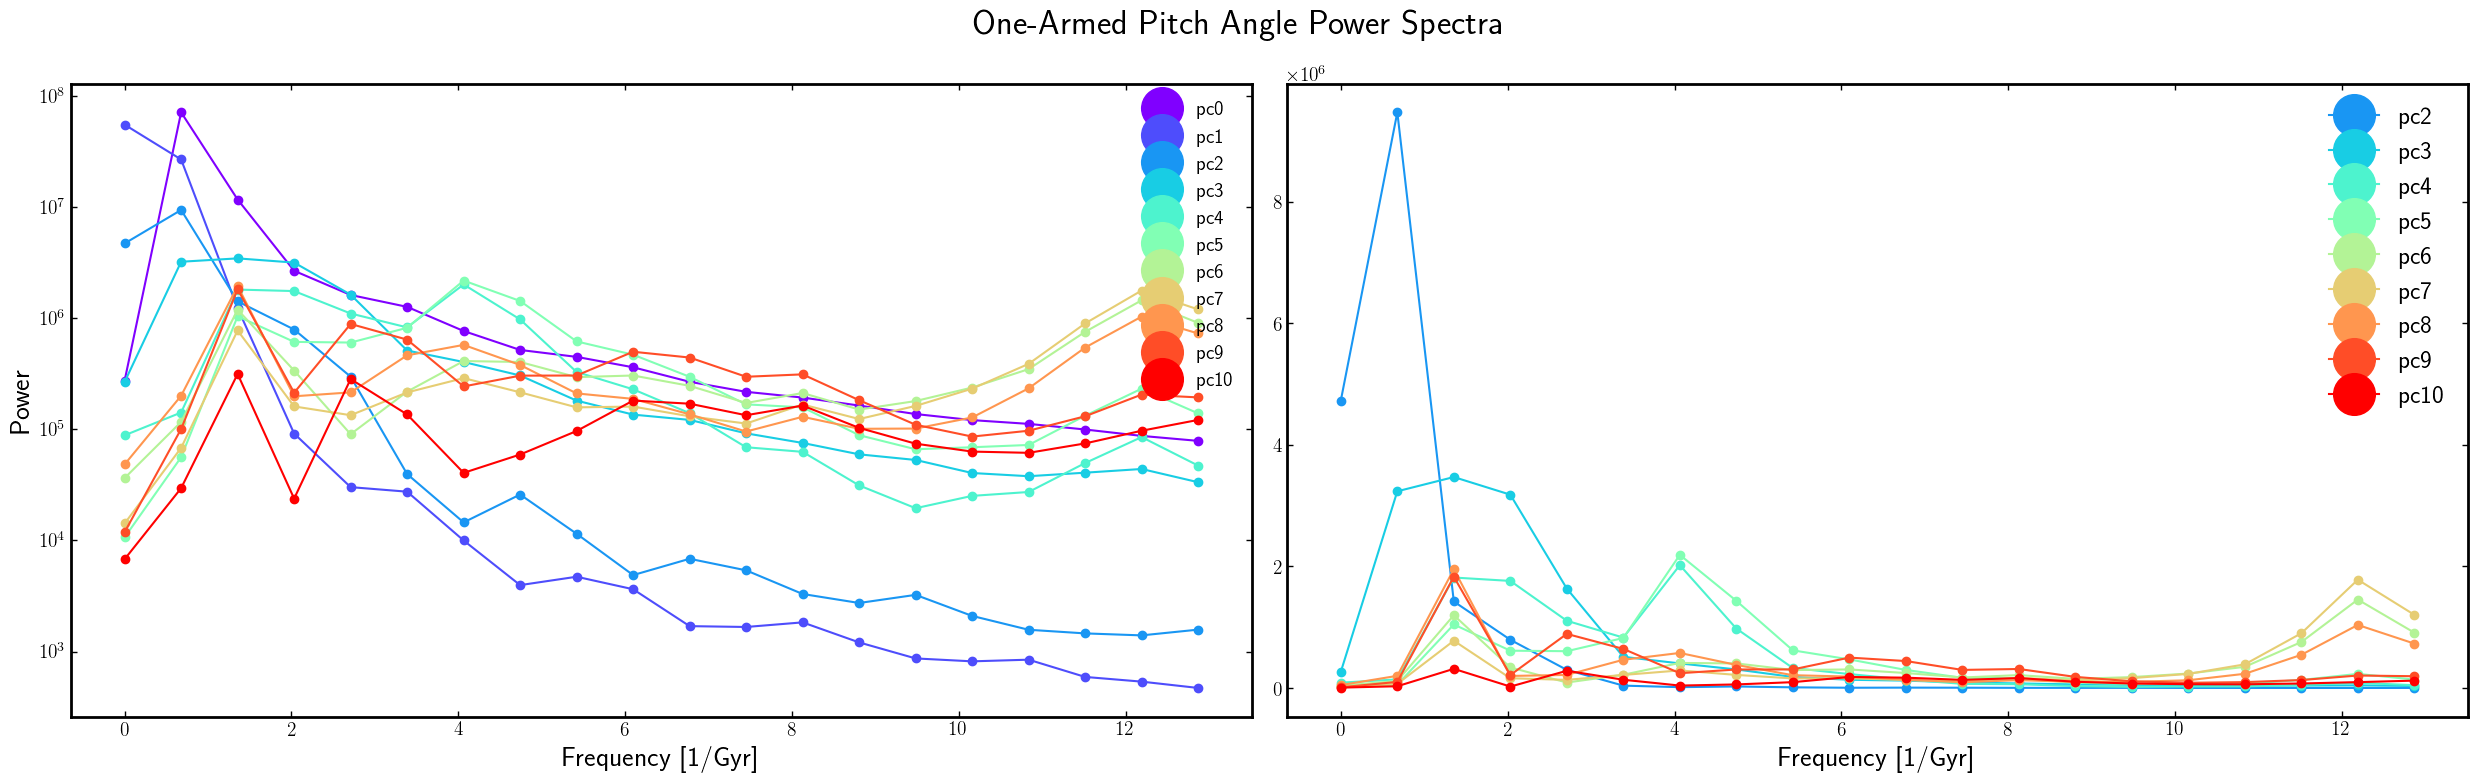

In [12]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Pitch Angle Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

### Face-on Plots

Updating for: (c)_0
Updating for: (s)_0
Updating for: (�)_0
Updating for: (
)_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ()_0
Updating for: (?)_0
Updating for: (^)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (v)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (Z)_0
Updating for: (&)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


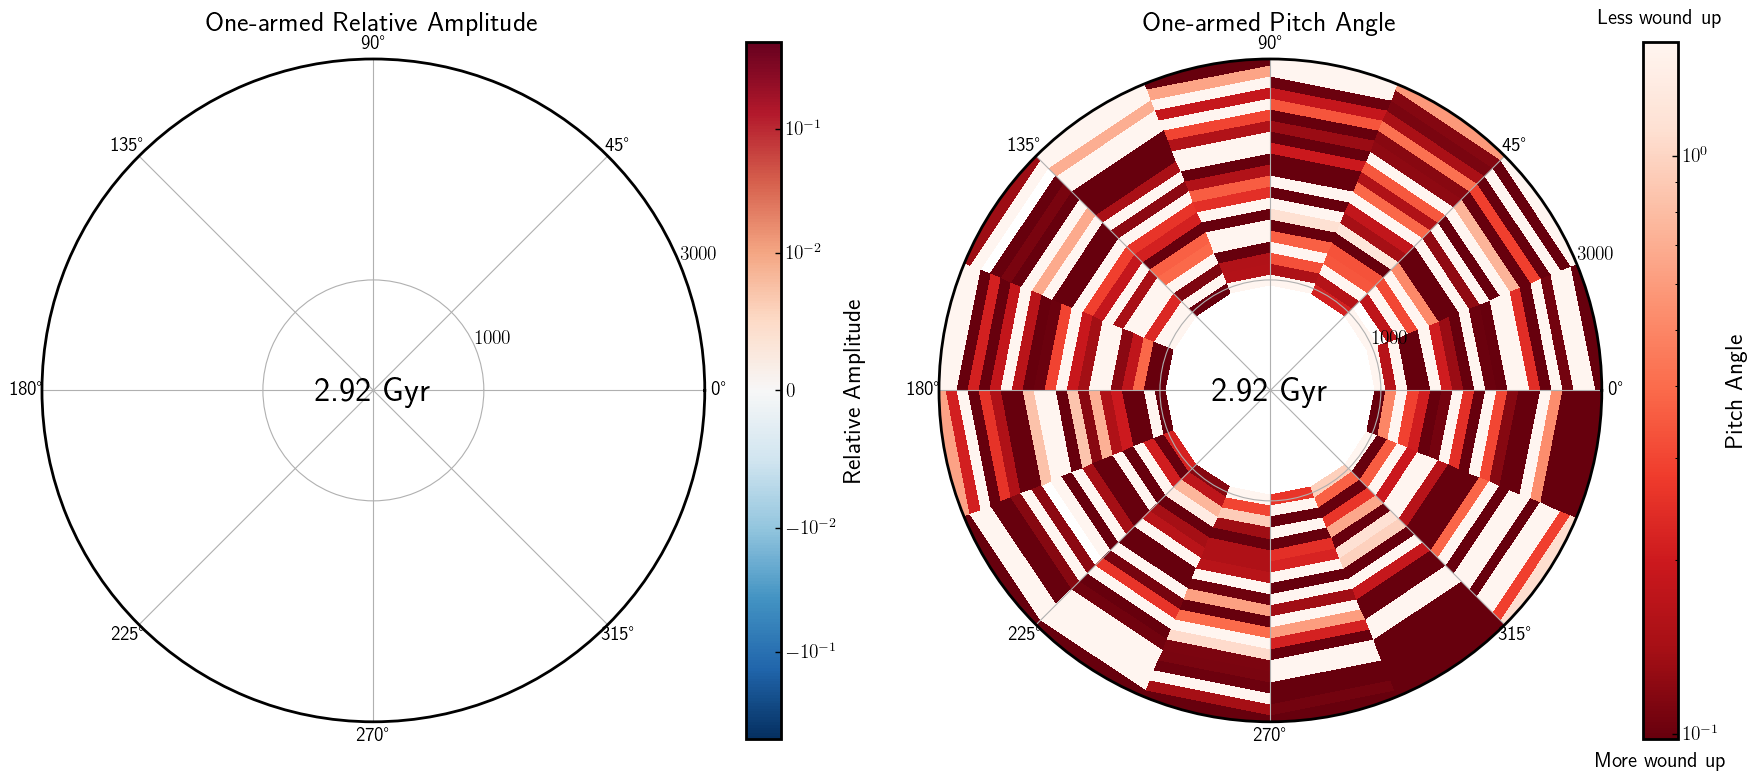

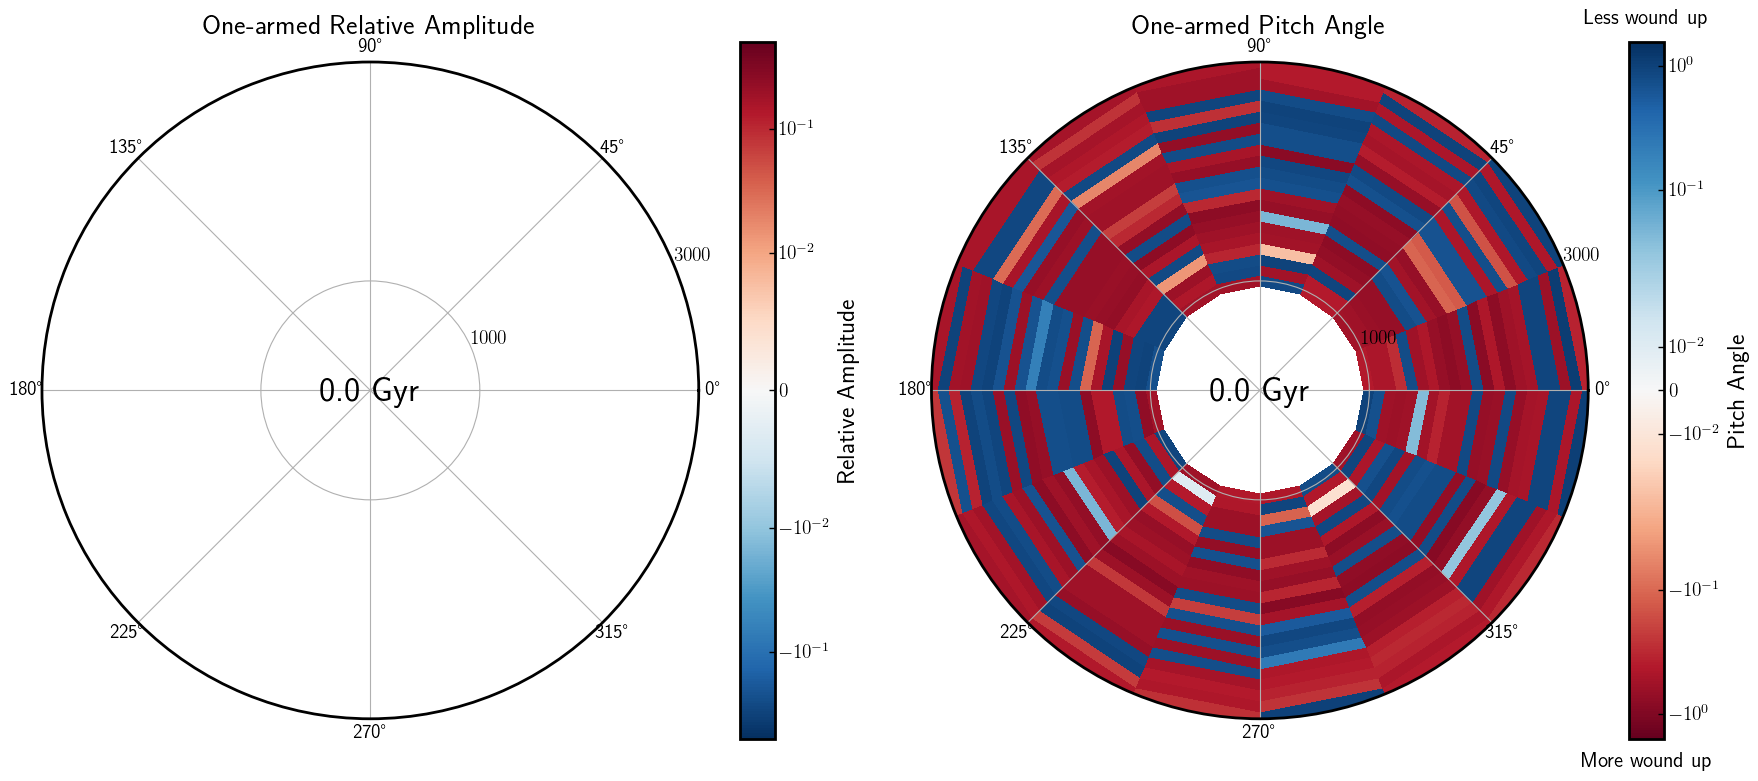

In [13]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_pitch = np.loadtxt(directory+'m1_pitch_bins_j20_t16.dat')
tbl_rel_amp = np.loadtxt(directory+'m1_amp_rel_bins_j20_t16.dat')

f = fig_dir+'face-on_plots/data_m1_pitch.mp4'
f_sub = fig_dir+'face-on_plots/data_m1_pitch_subtract_pc0-1.mp4'

MakeAnim = MakeAnimations(mssa, 'pitch', times, n_channels, [0,1], jbins=20)
MakeAnim.make_pre_mssa_face_on(f, tbl_rel_amp, tbl_pitch)
MakeAnim.make_pre_mssa_face_on_subtracted(f_sub, tbl_rel_amp, tbl_pitch)

Updating for: (c)_0
Updating for: (s)_0
Updating for: (�)_0
336
Making movies for just Amplitude or Pitch Angle
Updating for: (
)_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ()_0
Updating for: (?)_0
Updating for: (^)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (v)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (Z)_0
Updating for: (&)_0
Updating for: ()_0
Updating

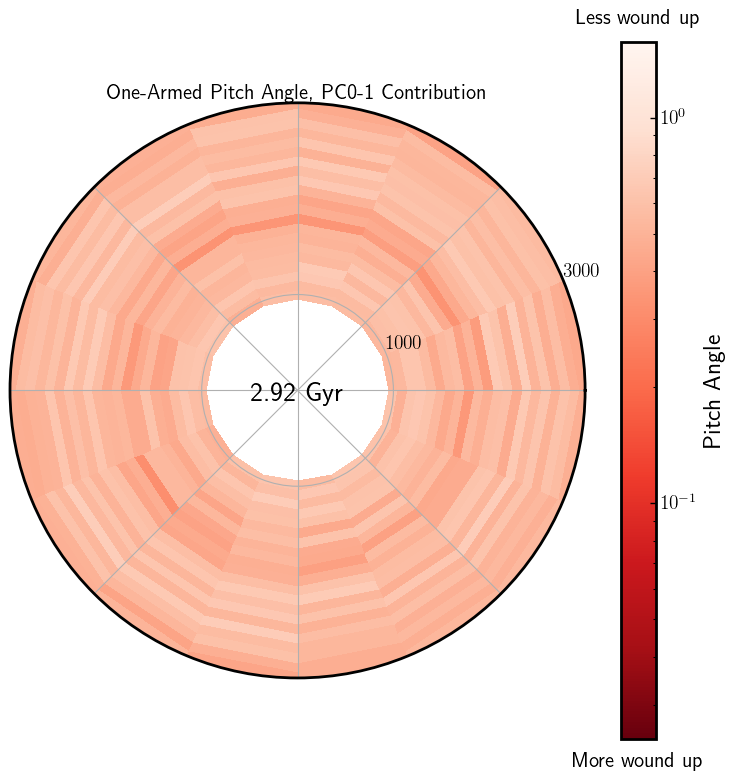

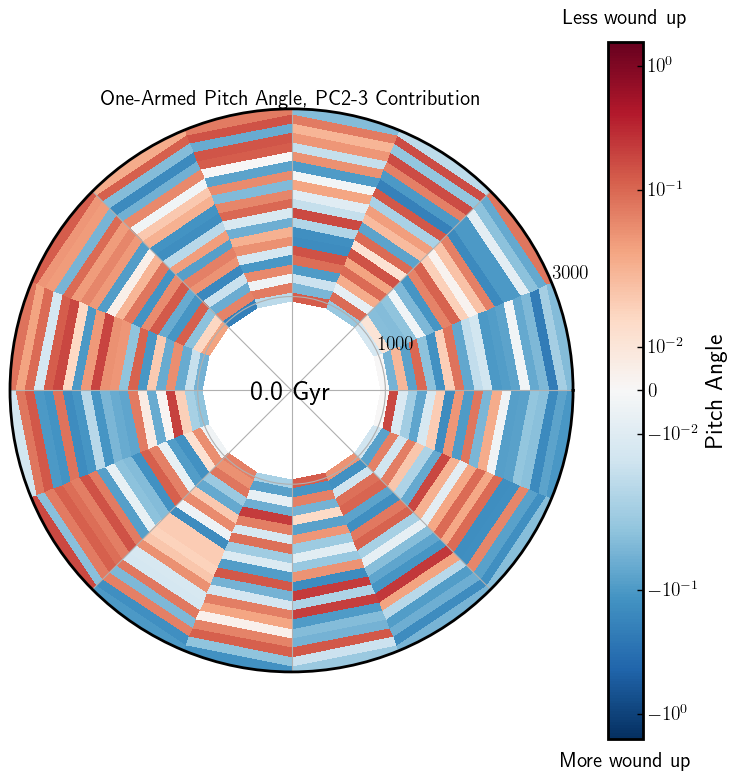

In [14]:
f = fig_dir+'face-on_plots/m1_pitch_pc0+pc1.mp4'
MakeAnim0 = MakeAnimations(mssa, 'pitch', times, n_channels, [0,1], jbins=20)
MakeAnim0.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_pitch_pc2+pc3.mp4'
MakeAnim1 = MakeAnimations(mssa, 'pitch', times, n_channels, [2,3], jbins=20)
MakeAnim1.make_recon_mov_disk_plot(f)